
Processing algorithm: CKE
  Found 8 CSV files in algorithm 'CKE'.
  Common users across files: 661 users
    Processed D:\master_reserch\data\genre_wise\results_top_n_genre_test_2\CKE\per_user_ndcg_scores_CKE_action.csv, STS array shape: (661,)
    Processed D:\master_reserch\data\genre_wise\results_top_n_genre_test_2\CKE\per_user_ndcg_scores_CKE_comedy.csv, STS array shape: (661,)
    Processed D:\master_reserch\data\genre_wise\results_top_n_genre_test_2\CKE\per_user_ndcg_scores_CKE_drama.csv, STS array shape: (661,)
    Processed D:\master_reserch\data\genre_wise\results_top_n_genre_test_2\CKE\per_user_ndcg_scores_CKE_mystery.csv, STS array shape: (661,)
    Processed D:\master_reserch\data\genre_wise\results_top_n_genre_test_2\CKE\per_user_ndcg_scores_CKE_romance.csv, STS array shape: (661,)
    Processed D:\master_reserch\data\genre_wise\results_top_n_genre_test_2\CKE\per_user_ndcg_scores_CKE_sci-fi.csv, STS array shape: (661,)
    Processed D:\master_reserch\data\genre_wise\resul

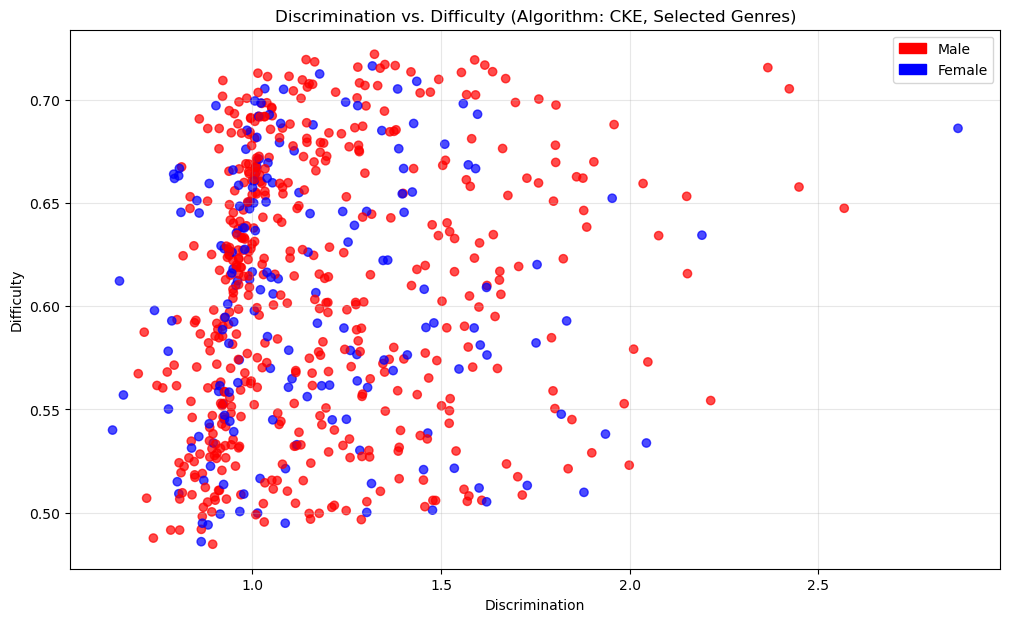


🎉 All algorithms processed successfully!


In [63]:
import os
import glob
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from irt import Beta3

# ------------------ 1) Configuration ------------------
#algos = ["Random", "Random_2", "CKE", "KGAT", "KGCN", "KGIN", "NCFKG"]

algos = ["CKE"]

#genres_to_use = ["action", "adventure", "animation", "children", "comedy", 
#                 "crime", "documentary", "drama", "fantasy", "filmnoir", "horror",
#                 "musical", "mystery", "romance", "sci-fi", "thriller", "war", "western"]

genres_to_use = ["action", "comedy", "drama","mystery", "romance",  "sci-fi", "thriller", "war"]


base_dir = os.path.abspath("../data/genre_wise/results_top_n_genre_test_2")
user_info_path = os.path.abspath("../data/user_info_existing.csv")

# ------------------ 2) Function Definitions ------------------
def compute_sts_matrix_from_csv(csv_path, user_ids_order=None):
    df = pd.read_csv(csv_path)
    if user_ids_order is not None:
        df = df[df["user_id"].isin(user_ids_order)]
        df = df.set_index("user_id").loc[user_ids_order].reset_index()
    
    ndcg_correct = torch.tensor(df["ndcg_correct"].values, dtype=torch.float32)
    ndcg_flipped = torch.tensor(df["ndcg_flipped"].values, dtype=torch.float32)
    alpha = 0.9
    sts_array = (1 - torch.abs(ndcg_correct - ndcg_flipped)) ** alpha
    return sts_array.numpy(), df["user_id"]

def loss_function(b4, df_matrix):
    loss_list = []
    for i in range(df_matrix.shape[0]):
        for j in range(df_matrix.shape[1]):
            pij_predicted = ICC_function(
                b4.abilities[j],
                b4.difficulties[i],
                b4.discriminations[i]
            )
            loss_list.append(abs(pij_predicted - df_matrix.iloc[i, j]))
    return np.mean(loss_list)

def ICC_function(abilities, difficulties, discriminations):
    a = (1 - abilities) / abilities
    b = difficulties / (1 - difficulties)
    c = a * b
    d = c ** discriminations
    return 1 / (d + 1)

# ------------------ 3) Process Each Algorithm ------------------
for algo_name in algos:
    algo_path = os.path.join(base_dir, algo_name)
    if not os.path.isdir(algo_path):
        print(f"⚠️ Directory not found: {algo_path}")
        continue

    print(f"\nProcessing algorithm: {algo_name}")
    
    pattern = os.path.join(algo_path, "per_user_ndcg_scores_*.csv")
    all_csv_files = glob.glob(pattern)

    csv_files = [
        f for f in all_csv_files 
        if any(genre in f.lower() for genre in genres_to_use)
    ]

    if not csv_files:
        print(f"  ⚠️ No CSV files found in algorithm '{algo_name}' for target genres, skipping...")
        continue

    print(f"  Found {len(csv_files)} CSV files in algorithm '{algo_name}'.")

    user_ids_intersection = None
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        current_ids = set(df["user_id"])
        if user_ids_intersection is None:
            user_ids_intersection = current_ids
        else:
            user_ids_intersection = user_ids_intersection.intersection(current_ids)
    
    if not user_ids_intersection:
        print(f"  ⚠️ No common user_ids found across files in algorithm '{algo_name}', skipping...")
        continue

    common_user_ids = sorted(user_ids_intersection)
    print(f"  Common users across files: {len(common_user_ids)} users")

    list_of_sts_arrays = []
    for csv_file in csv_files:
        sts_array, _ = compute_sts_matrix_from_csv(csv_file, user_ids_order=common_user_ids)
        list_of_sts_arrays.append(sts_array)
        print(f"    Processed {csv_file}, STS array shape: {sts_array.shape}")

    final_matrix = np.vstack(list_of_sts_arrays).T
    print(f"  Final STS matrix shape in algorithm '{algo_name}': {final_matrix.shape}")

    normalized_df = pd.DataFrame(final_matrix)
    subjects = normalized_df.shape[1]
    items = normalized_df.shape[0]

    b4 = Beta3(
        learning_rate=10,
        epochs=5000,
        n_respondents=subjects,
        n_items=items,
        n_workers=-1,
        random_seed=1,
    )

    print(f"  Fitting Beta3 model in algorithm '{algo_name}'...")
    b4.fit(normalized_df.values)
    print(f"  Model fitting complete in algorithm '{algo_name}'.")

    loss = loss_function(b4, normalized_df)
    print(f"  Final loss in algorithm '{algo_name}': {loss}")

    if not os.path.exists(user_info_path):
        print(f"  ⚠️ user_info_existing.csv not found at {user_info_path}, skipping merge.")
        continue

    user_info = pd.read_csv(user_info_path)
    user_beta3_results = pd.DataFrame({
        "user_id": common_user_ids,
        "discrimination": b4.discriminations,
        "difficulty": b4.difficulties
    })

    merged_df = user_beta3_results.merge(user_info, on="user_id", how="left")

    # ------------------ Display Plot ------------------
    disc_values = np.array(merged_df["discrimination"])
    difficulty_values = np.array(merged_df["difficulty"])
    user_genders = np.array(merged_df["gender"])
    colors = np.where(user_genders == 0, "red", "blue")  # assuming 0=Male, 1=Female

    plt.figure(figsize=(12, 7))
    plt.scatter(disc_values, difficulty_values, c=colors, alpha=0.7)
    plt.title(f"Discrimination vs. Difficulty (Algorithm: {algo_name}, Selected Genres)")
    plt.xlabel("Discrimination")
    plt.ylabel("Difficulty")
    plt.grid(alpha=0.3)

    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color="red", label="Male")
    blue_patch = mpatches.Patch(color="blue", label="Female")
    plt.legend(handles=[red_patch, blue_patch])

    plt.show()

print("\n🎉 All algorithms processed successfully!")


In [68]:
import numpy as np

# Define line endpoints (from your image)
# KGAT line coordinates
x1, y1 = 0.85, 0.49
x2, y2 = 1.06, 0.715




# Line vector and unit vector
dx = x2 - x1
dy = y2 - y1
line_vec = np.array([dx, dy])
line_unit_vec = line_vec / np.linalg.norm(line_vec)

# Function to calculate perpendicular distance from a point to the line
def point_line_distance(px, py):
    # Vector from (x1, y1) to point
    point_vec = np.array([px - x1, py - y1])
    # Projection onto the line
    proj_length = np.dot(point_vec, line_unit_vec)
    proj_point = np.array([x1, y1]) + proj_length * line_unit_vec
    distance = np.linalg.norm(point_vec - proj_length * line_unit_vec)
    return distance

# Apply to all users
merged_df["distance_to_line"] = merged_df.apply(
    lambda row: point_line_distance(row["discrimination"], row["difficulty"]), axis=1
)

# Threshold: only keep users within 0.02 distance of the line
line_cluster_df = merged_df[merged_df["distance_to_line"] < 0.04]

# Output
print(f"📏 Found {len(line_cluster_df)} users aligned closely to the line.")
print(line_cluster_df[["user_id", "discrimination", "difficulty", "distance_to_line"]])


📏 Found 229 users aligned closely to the line.
     user_id  discrimination  difficulty  distance_to_line
0          0        0.899709    0.527698          0.010618
1          1        0.864496    0.485959          0.013355
3          3        1.003529    0.637942          0.011294
5          5        0.989677    0.605341          0.023413
7          8        1.021960    0.660478          0.009392
..       ...             ...         ...               ...
647      924        0.979941    0.627577          0.001123
648      926        0.940171    0.555819          0.021011
650      928        1.020378    0.691776          0.013119
654      935        0.840132    0.508686          0.019963
656      937        0.938351    0.558421          0.017904

[229 rows x 4 columns]


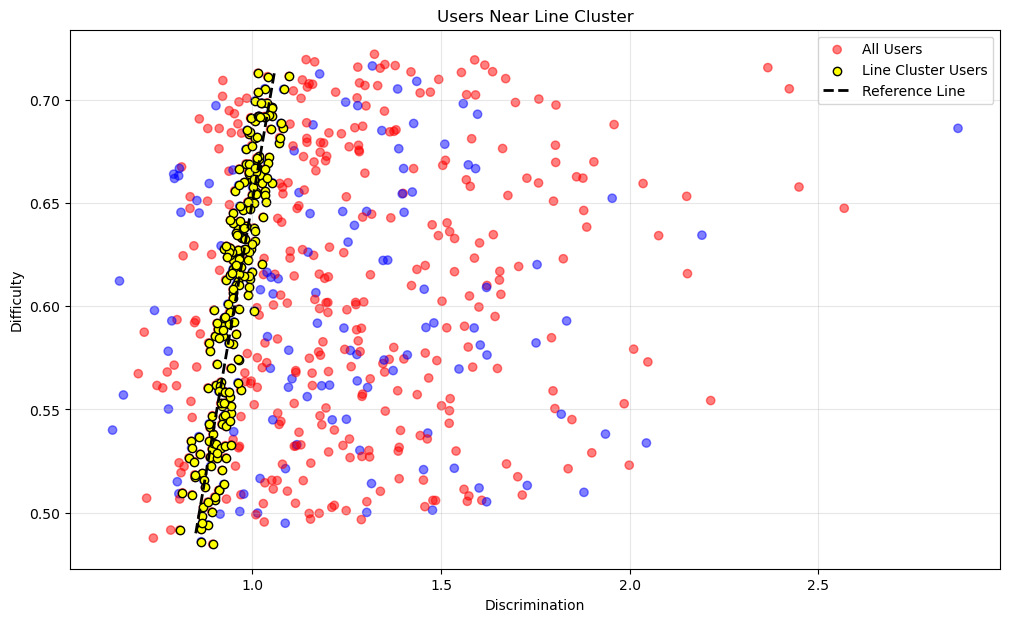

In [69]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot all points
plt.figure(figsize=(12, 7))
colors = np.where(merged_df["gender"] == 0, "red", "blue")
plt.scatter(merged_df["discrimination"], merged_df["difficulty"], c=colors, alpha=0.5, label="All Users")

# Highlight line-cluster users
plt.scatter(line_cluster_df["discrimination"], line_cluster_df["difficulty"], 
            edgecolors="black", facecolors="yellow", label="Line Cluster Users")

# Draw the line
plt.plot([x1, x2], [y1, y2], color="black", linestyle="--", linewidth=2, label="Reference Line")

# Labels and legend
plt.title("Users Near Line Cluster")
plt.xlabel("Discrimination")
plt.ylabel("Difficulty")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [53]:
line_cluster_df

,user_id,discrimination,difficulty,gender,occupation,zip_code,age,distance_to_line
0,0,0.875361,0.529005,0,19,622,24,0.040848
1,1,0.887767,0.484916,1,13,689,53,0.008049
2,2,0.880458,0.520760,0,20,270,23,0.032309
3,3,0.995369,0.638565,0,19,331,24,0.008253
7,8,1.013540,0.661132,0,18,1,29,0.012697
...,...,...,...,...,...,...,...,...
648,926,0.917968,0.557121,0,14,444,23,0.018022
650,928,1.003526,0.692861,0,17,403,44,0.011847
654,935,0.885618,0.506655,0,13,278,24,0.020785
656,937,0.923580,0.559305,1,19,413,38,0.014255


In [70]:
import pandas as pd

# Load your full rating dataset (with genre columns)
df = pd.read_csv("../data/processed_data.csv")



# Define genre columns
genre_columns = [
    "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical",
    "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

# 1. Total ratings per user
user_rating_count = df.groupby("user_id").size().reset_index(name="total_rated")

# 2. Genre-wise counts
user_genre_counts = df.groupby("user_id")[genre_columns].sum().reset_index()

# 3. Combine counts into one dataframe
user_stats = pd.merge(user_rating_count, user_genre_counts, on="user_id")

# 4. Merge stats into your existing `line_cluster_df`
line_cluster_merged = pd.merge(line_cluster_df, user_stats, on="user_id", how="left")

# 5. Save final enriched file
line_cluster_merged.to_csv("../data/algo_wise/cluster/user_info/line_cluster_users_enriched_CKE.csv", index=False)
print("✅ Saved enriched line cluster data to 'line_cluster_users_enriched.csv'")



✅ Saved enriched line cluster data to 'line_cluster_users_enriched.csv'
